<a href="https://colab.research.google.com/github/OJB-Quantum/Monte-Carlo-Sim/blob/main/JJ_Quantum_Tunneling_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
import pandas as pd

In [2]:
# Onri prefers using rcParams to increase the quality of all plots to be higher than the default settings.
# This only needs to be done once at beginning of every Jupyter Notebook.
plt.rcParams['figure.dpi'] = 200

# High contrast plotting style via rcParams
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['figure.facecolor'] = '#000000'
plt.rcParams['axes.facecolor'] = '#000000'
plt.rcParams['axes.edgecolor'] = '#FFFFFF'
plt.rcParams['axes.labelcolor'] = '#FFFFFF'
plt.rcParams['xtick.color'] = '#FFFFFF'
plt.rcParams['ytick.color'] = '#FFFFFF'
plt.rcParams['text.color'] = '#FFFFFF'
plt.rcParams['font.size'] = 14
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['lines.linewidth'] = 2.0
plt.rcParams['grid.color'] = '#444444'

Equations Used in Josephson Junction Analysis

1. Josephson Current Density

The Josephson current is given by:

$$
I_s=I_c \sin (\phi)
$$

where:
$I_c$ : Critical current
$\phi$ : Phase difference between the two superconductors

2. Critical Current

The critical current $I_c$ is calculated using:

$$
I_c=\frac{\pi \Delta_1 \Delta_2}{2 e R_N k_B T} \tanh \left(\frac{\Delta}{2 k_B T}\right)
$$

where:
$\Delta_1, \Delta_2$ : Superconducting gaps of the metal nitride layers
$R_N$ : Normal-state resistance of the junction
$k_B$ Boltzmann constant
$T$ : Temperature
$e$ : Elementary charge

3. Tunneling Probability

The tunneling probability $T(E)$ for an electron is given by:

$$
T(E)=\exp \left(-2 \sqrt{2 m} \int_{z_1}^{z_2} \sqrt{V(z)-E} d z\right)
$$

where:
$m$ : Effective electron mass
$V(z)$ : Potential barrier profile
$E$ : Electron energy
In this simplified analysis, the potential $V(z)$ is treated as constant, leading to:

$$
T(E)=\exp (-2 \sqrt{2 m(V-E)} \cdot d / \hbar)
$$

where:
$d$ : Barrier thickness
ћ: Reduced Planck constant

4. Simplified Critical Current Estimate

The tunneling probability from the Monte Carlo simulation is incorporated into the critical current formula as:

$$
I_c=\left(\frac{\pi \Delta_1 \Delta_2}{2 e R_N k_B T}\right) \cdot\langle T(E)\rangle
$$

where:
$\langle T(E)\rangle$ : Average tunneling probability from Monte Carlo simulation

5. Polynomial Regression Model

To approximate the nonlinear relationship between critical current $I_c$ and barrier thickness $d$, a polynomial regression model of degree $n$ is used:

$$
I_c=a_0+a_1 d+a_2 d^2+\ldots+a_n d^n
$$

where $a_i$ are the coefficients learned from the data.

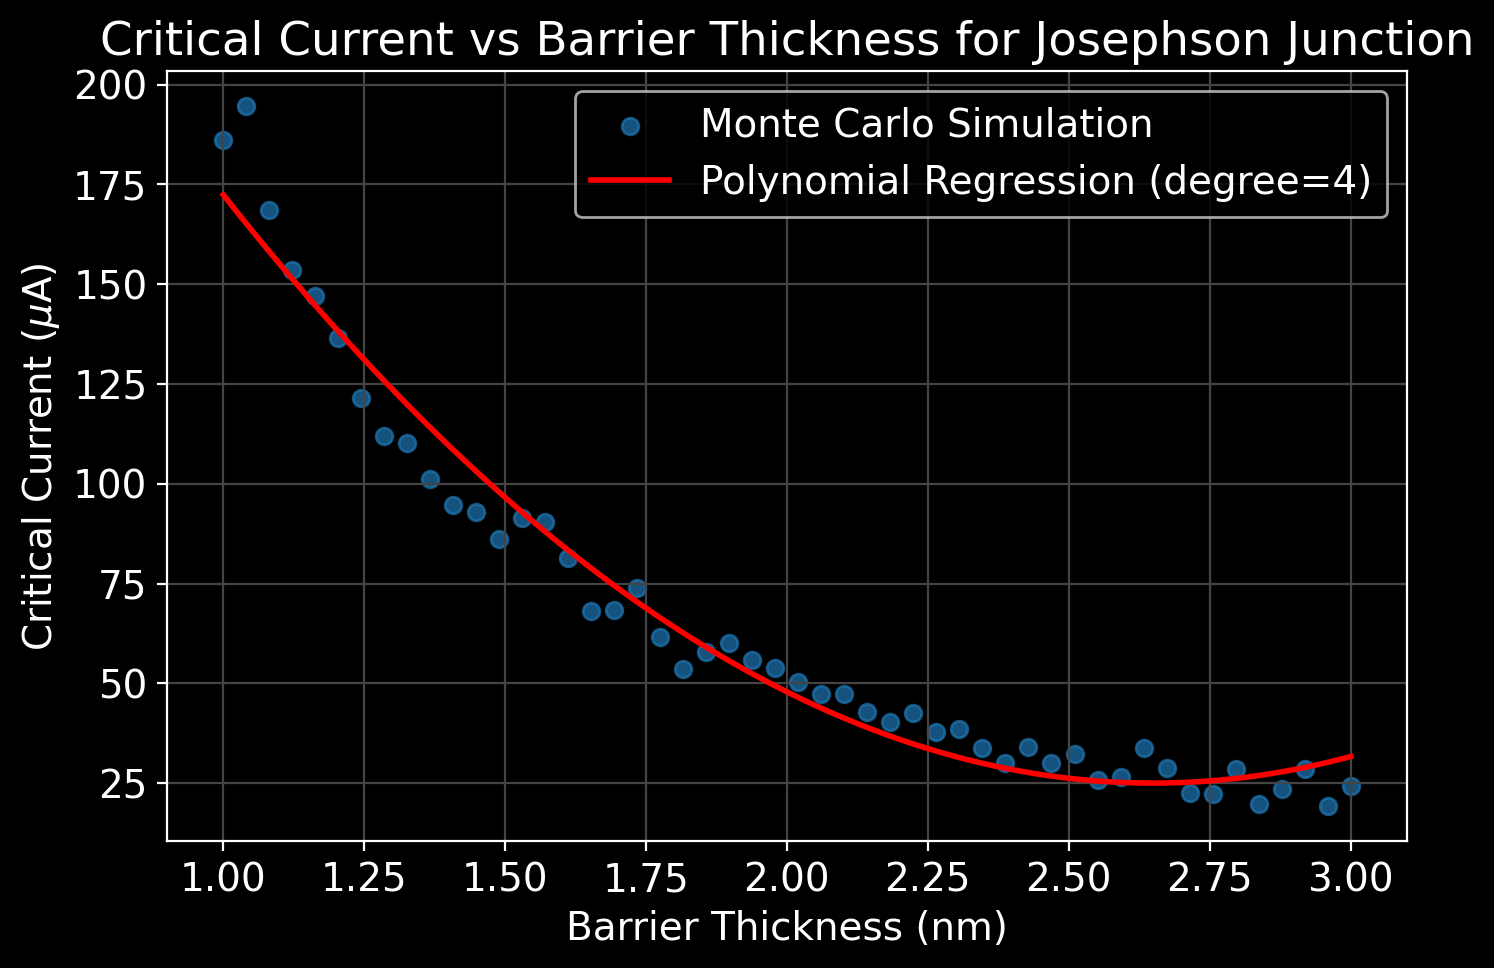

   Barrier Thickness (nm)  Critical Current (uA)
0                1.000000             186.115933
1                1.040816             194.534330
2                1.081633             168.540763
3                1.122449             153.529045
4                1.163265             147.140062


In [3]:
# Constants
e = 1.602e-19  # Charge of electron (Coulombs)
k_B = 1.381e-23  # Boltzmann constant (J/K)
hbar = 1.054e-34  # Reduced Planck's constant (Js)
m_e = 9.109e-31  # Electron mass (kg)
T_fixed = 4.2  # Temperature (K), typical for LN2 cooling
V_barrier = 1.5e-19  # Barrier height (J), typical for AlN
d_values = np.linspace(1e-9, 3e-9, 50)  # Barrier thickness range (m)
Delta1, Delta2 = 1.5e-3 * e, 1.5e-3 * e  # Superconducting gap (J)
R_N = 1.0  # Normal resistance (Ohms)

# Monte Carlo Simulation for tunneling probability
def tunneling_probability(V, E, d, m=m_e):
    """Calculates tunneling probability for an electron."""
    if E >= V:
        return 1  # No barrier
    return np.exp(-2 * np.sqrt(2 * m) * np.sqrt(V - E) * d / hbar)

# Simulate tunneling and critical current
np.random.seed(42)
n_samples = 10000
data = []  # To store generated dataset
for d in d_values:
    # Monte Carlo sampling for electron energy
    energies = np.random.uniform(0, V_barrier, n_samples)
    probabilities = [tunneling_probability(V_barrier, E, d) for E in energies]
    average_tunneling_prob = np.mean(probabilities)
    # Calculate critical current using the simplified tunneling formula
    Ic = (np.pi * Delta1 * Delta2 / (2 * e * R_N * k_B * T_fixed)) * average_tunneling_prob
    data.append([d, T_fixed, Delta1, Delta2, R_N, Ic])

# Convert to NumPy array for machine learning
data = np.array(data)
d_values, Ic_values = data[:, 0], data[:, -1]

# Polynomial Regression Model
X = d_values.reshape(-1, 1)  # Use only thickness as a feature for simplicity
y = Ic_values
degree = 4 # Polynomial degree
model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
model.fit(X, y)

# Predictions using the trained model
d_test = np.linspace(1e-9, 3e-9, 100).reshape(-1, 1)
Ic_pred = model.predict(d_test)

# Visualize results
plt.figure(figsize=(8, 5))
plt.scatter(d_values * 1e9, Ic_values * 1e6, label="Monte Carlo Simulation", alpha=0.7)
plt.plot(d_test.flatten() * 1e9, Ic_pred * 1e6, label=f"Polynomial Regression (degree={degree})", color="red")
plt.xlabel("Barrier Thickness (nm)")
plt.ylabel("Critical Current ($\mu$A)")
plt.title("Critical Current vs Barrier Thickness for Josephson Junction")
plt.legend()
plt.grid()
plt.show()

# Present data as a pandas DataFrame
results_df = pd.DataFrame({
    "Barrier Thickness (nm)": d_values * 1e9,
    "Critical Current (uA)": Ic_values * 1e6
})

# Print the DataFrame
print(results_df.head())  # Display first few rows


CPU Monte Carlo completed in 0.0111 seconds
GPU Monte Carlo completed in 0.0379 seconds
Speedup: CPU_time / GPU_time = 0.29x


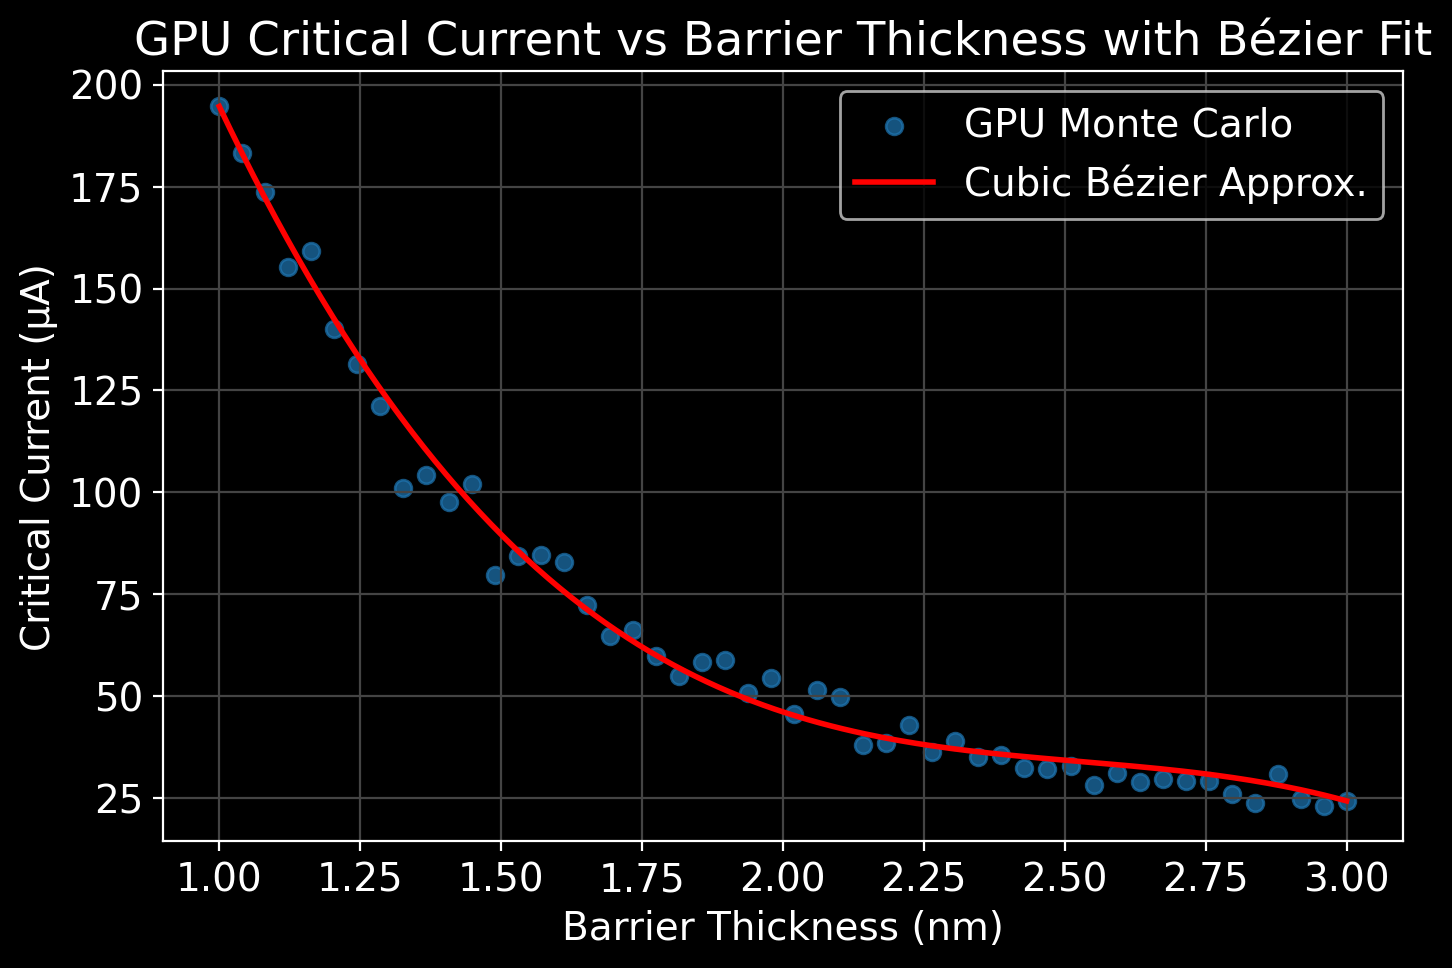

   Barrier Thickness (nm)  Ic_CPU (μA)  Ic_GPU (μA)
0                1.000000   186.115933   194.670220
1                1.040816   194.534330   183.134077
2                1.081633   168.540763   173.643748
3                1.122449   153.529045   155.370229
4                1.163265   147.140062   159.210412


In [12]:
# CUDA Python GPU Comparison for Monte Carlo Simulation
# This code cell is intended for Google Colab with GPU runtime enabled.

# 1) Install required packages (CuPy, scikit-learn, and SciPy for fitting)
!pip install cupy-cuda11x scikit-learn scipy --quiet

# 2) Imports for CPU, GPU, and fitting
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
import pandas as pd
import time
import scipy.optimize as opt

# 3) Constants
e = 1.602e-19  # Charge of electron (Coulombs)
k_B = 1.381e-23  # Boltzmann constant (J/K)
hbar = 1.054e-34  # Reduced Planck's constant (Js)
m_e = 9.109e-31  # Electron mass (kg)
T_fixed = 4.2  # Temperature (K)
V_barrier = 1.5e-19  # Barrier height (J)
R_N = 1.0  # Normal resistance (Ohms)
Delta1 = 1.5e-3 * e
Delta2 = 1.5e-3 * e

# 4) Range of barrier thickness values
d_values = np.linspace(1e-9, 3e-9, 50)

# 5) CPU Monte Carlo Version
def tunneling_probability_cpu(V, E, d, m=m_e):
    """Calculates tunneling probability for an electron on CPU."""
    prob = np.ones_like(E)
    mask = E < V
    prob[mask] = np.exp(-2 * np.sqrt(2 * m) * np.sqrt(V - E[mask]) * d / hbar)
    return prob

# Run CPU Monte Carlo
tic_cpu = time.time()
results_cpu = []
np.random.seed(42)
n_samples = 10000
for d in d_values:
    energies_cpu = np.random.uniform(0, V_barrier, n_samples)
    probs_cpu = tunneling_probability_cpu(V_barrier, energies_cpu, d)
    avg_prob_cpu = np.mean(probs_cpu)
    Ic_cpu = (np.pi * Delta1 * Delta2 / (2 * e * R_N * k_B * T_fixed)) * avg_prob_cpu
    results_cpu.append(Ic_cpu)
toc_cpu = time.time()
CPU_time = toc_cpu - tic_cpu
print(f"CPU Monte Carlo completed in {CPU_time:.4f} seconds")

# 6) GPU Monte Carlo Version using CuPy
def tunneling_probability_gpu(V, E_gpu, d, m=m_e):
    """Calculates tunneling probability for an electron on GPU."""
    prob_gpu = cp.ones_like(E_gpu)
    mask_gpu = E_gpu < V
    sqrt_term = cp.sqrt(V - E_gpu[mask_gpu])
    prob_gpu[mask_gpu] = cp.exp(-2 * cp.sqrt(2 * m) * sqrt_term * d / hbar)
    return prob_gpu

# Run GPU Monte Carlo
cp.random.seed(42)
tic_gpu = time.time()
results_gpu = []
n_samples_gpu = 10000
for d in d_values:
    energies_gpu = cp.random.uniform(0, V_barrier, n_samples_gpu)
    probs_gpu = tunneling_probability_gpu(V_barrier, energies_gpu, d)
    avg_prob_gpu = cp.mean(probs_gpu)
    Ic_gpu = (np.pi * Delta1 * Delta2 / (2 * e * R_N * k_B * T_fixed)) * avg_prob_gpu
    results_gpu.append(cp.asnumpy(Ic_gpu))
cp.cuda.Stream.null.synchronize()
toc_gpu = time.time()
GPU_time = toc_gpu - tic_gpu
print(f"GPU Monte Carlo completed in {GPU_time:.4f} seconds")

# 7) Compare CPU vs GPU Times
print(f"Speedup: CPU_time / GPU_time = {CPU_time / GPU_time:.2f}x")

# 8) Convert results to arrays for fitting and visualization
results_cpu = np.array(results_cpu)
results_gpu = np.array(results_gpu)

# 9) Bézier Curve Approximation (Onri's method)
def bezier_y(t, P0_y, P1_y, P2_y, P3_y):
    """Compute cubic Bézier in 1D (y values) at parameters t."""
    return ((1 - t)**3) * P0_y + 3 * ((1 - t)**2) * t * P1_y + 3 * (1 - t) * (t**2) * P2_y + (t**3) * P3_y


def fit_bezier_1d(x, y):
    """Fit a 1D cubic Bézier to data (x, y) by optimizing the two middle control points."""
    # Normalize x to parameter t in [0,1]
    t = (x - x.min()) / (x.max() - x.min())
    P0_y = y[0]
    P3_y = y[-1]

    # Objective: sum of squared errors between y and Bézier y
    def obj(params):
        P1_y, P2_y = params
        y_fit = bezier_y(t, P0_y, P1_y, P2_y, P3_y)
        return np.sum((y - y_fit)**2)

    # Initial guesses via linear interpolation: y1 at t=1/3, y2 at t=2/3
    P1_0 = np.interp(1/3, t, y)
    P2_0 = np.interp(2/3, t, y)
    res = opt.minimize(obj, x0=[P1_0, P2_0])

    P1_y_opt, P2_y_opt = res.x
    return P0_y, P1_y_opt, P2_y_opt, P3_y

# Fit Bézier to GPU results (d_values vs results_gpu)
P0_y, P1_y, P2_y, P3_y = fit_bezier_1d(d_values, results_gpu)

# Generate dense curve for plotting
d_dense = np.linspace(d_values.min(), d_values.max(), 200)
t_dense = (d_dense - d_values.min()) / (d_values.max() - d_values.min())
Ic_bezier = bezier_y(t_dense, P0_y, P1_y, P2_y, P3_y)

# 10) Visualization
plt.figure(figsize=(8, 5))
# Plot original Monte Carlo points (GPU)
plt.scatter(d_values * 1e9, results_gpu * 1e6, label="GPU Monte Carlo", alpha=0.7)
# Plot Bézier approximation
plt.plot(d_dense * 1e9, Ic_bezier * 1e6, label="Cubic Bézier Approx.", color="red", linewidth=2)
plt.xlabel("Barrier Thickness (nm)")
plt.ylabel("Critical Current (μA)")
plt.title("GPU Critical Current vs Barrier Thickness with Bézier Fit")
plt.legend()
plt.grid()
plt.show()

# 11) DataFrame of results
results_df = pd.DataFrame({
    "Barrier Thickness (nm)": d_values * 1e9,
    "Ic_CPU (μA)": results_cpu * 1e6,
    "Ic_GPU (μA)": results_gpu * 1e6
})

print(results_df.head())